In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sys.path.append(os.path.abspath("../dataset and other libs"))
from cleaningcls import clean_cls
from ctf import CorrelationThresholdFilter
from pridict_thresh import pridict_thresh


In [2]:
# Load raw dataset
df = pd.read_csv('D:/Repos/Chrun-Pridictor/dataset and other libs/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("\nTarget distribution in train set:")
print(y_train.value_counts(normalize=True).round(3))

Training set shape: (5634, 20)
Test set shape: (1409, 20)

Target distribution in train set:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [3]:
import fastapi

pipeline_dt = Pipeline([
    ('clean', clean_cls()),
    ('ctf', CorrelationThresholdFilter(threshold=0.14)),
    ('pridict_thresh', pridict_thresh(RandomForestClassifier(
            n_estimators=200,           # More trees for stability
            max_depth=8,             # Prevent hyper-specific splits
            class_weight='balanced',    # Handle churn class imbalance
            random_state=42), thresh=0.64))])    
pipeline_dt.fit(X_train, y_train)

y_prob_dt_train = pipeline_dt.predict_proba(X_train)[:,1]
y_pred_dt_train = pipeline_dt.predict(X_train)
# y_pred_dt = (pipeline_dt.predict_proba(X_test)[: , 1] > 0.45).astype(int)

auc_dt = roc_auc_score(y_train, y_prob_dt_train)
print('=== Pipeline Evaluation ===')
print(f'ROC-AUC Score: {auc_dt:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_train, y_pred_dt_train))
print('\nClassification Report:')
print(classification_report(y_train, y_pred_dt_train))

print('=='*40)
print('TEST')
y_prob_dt = pipeline_dt.predict_proba(X_test)[:,1]
y_pred_dt = pipeline_dt.predict(X_test)
# y_pred_dt = (pipeline_dt.predict_proba(X_test)[: , 1] > 0.45).astype(int)

auc_dt = roc_auc_score(y_test, y_prob_dt)
print('=== Pipeline Evaluation ===')
print(f'ROC-AUC Score: {auc_dt:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))

=== Pipeline Evaluation ===
ROC-AUC Score: 0.8942

Confusion Matrix:
[[3645  494]
 [ 495 1000]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4139
           1       0.67      0.67      0.67      1495

    accuracy                           0.82      5634
   macro avg       0.77      0.77      0.77      5634
weighted avg       0.82      0.82      0.82      5634

TEST
=== Pipeline Evaluation ===
ROC-AUC Score: 0.8423

Confusion Matrix:
[[896 139]
 [138 236]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1035
           1       0.63      0.63      0.63       374

    accuracy                           0.80      1409
   macro avg       0.75      0.75      0.75      1409
weighted avg       0.80      0.80      0.80      1409



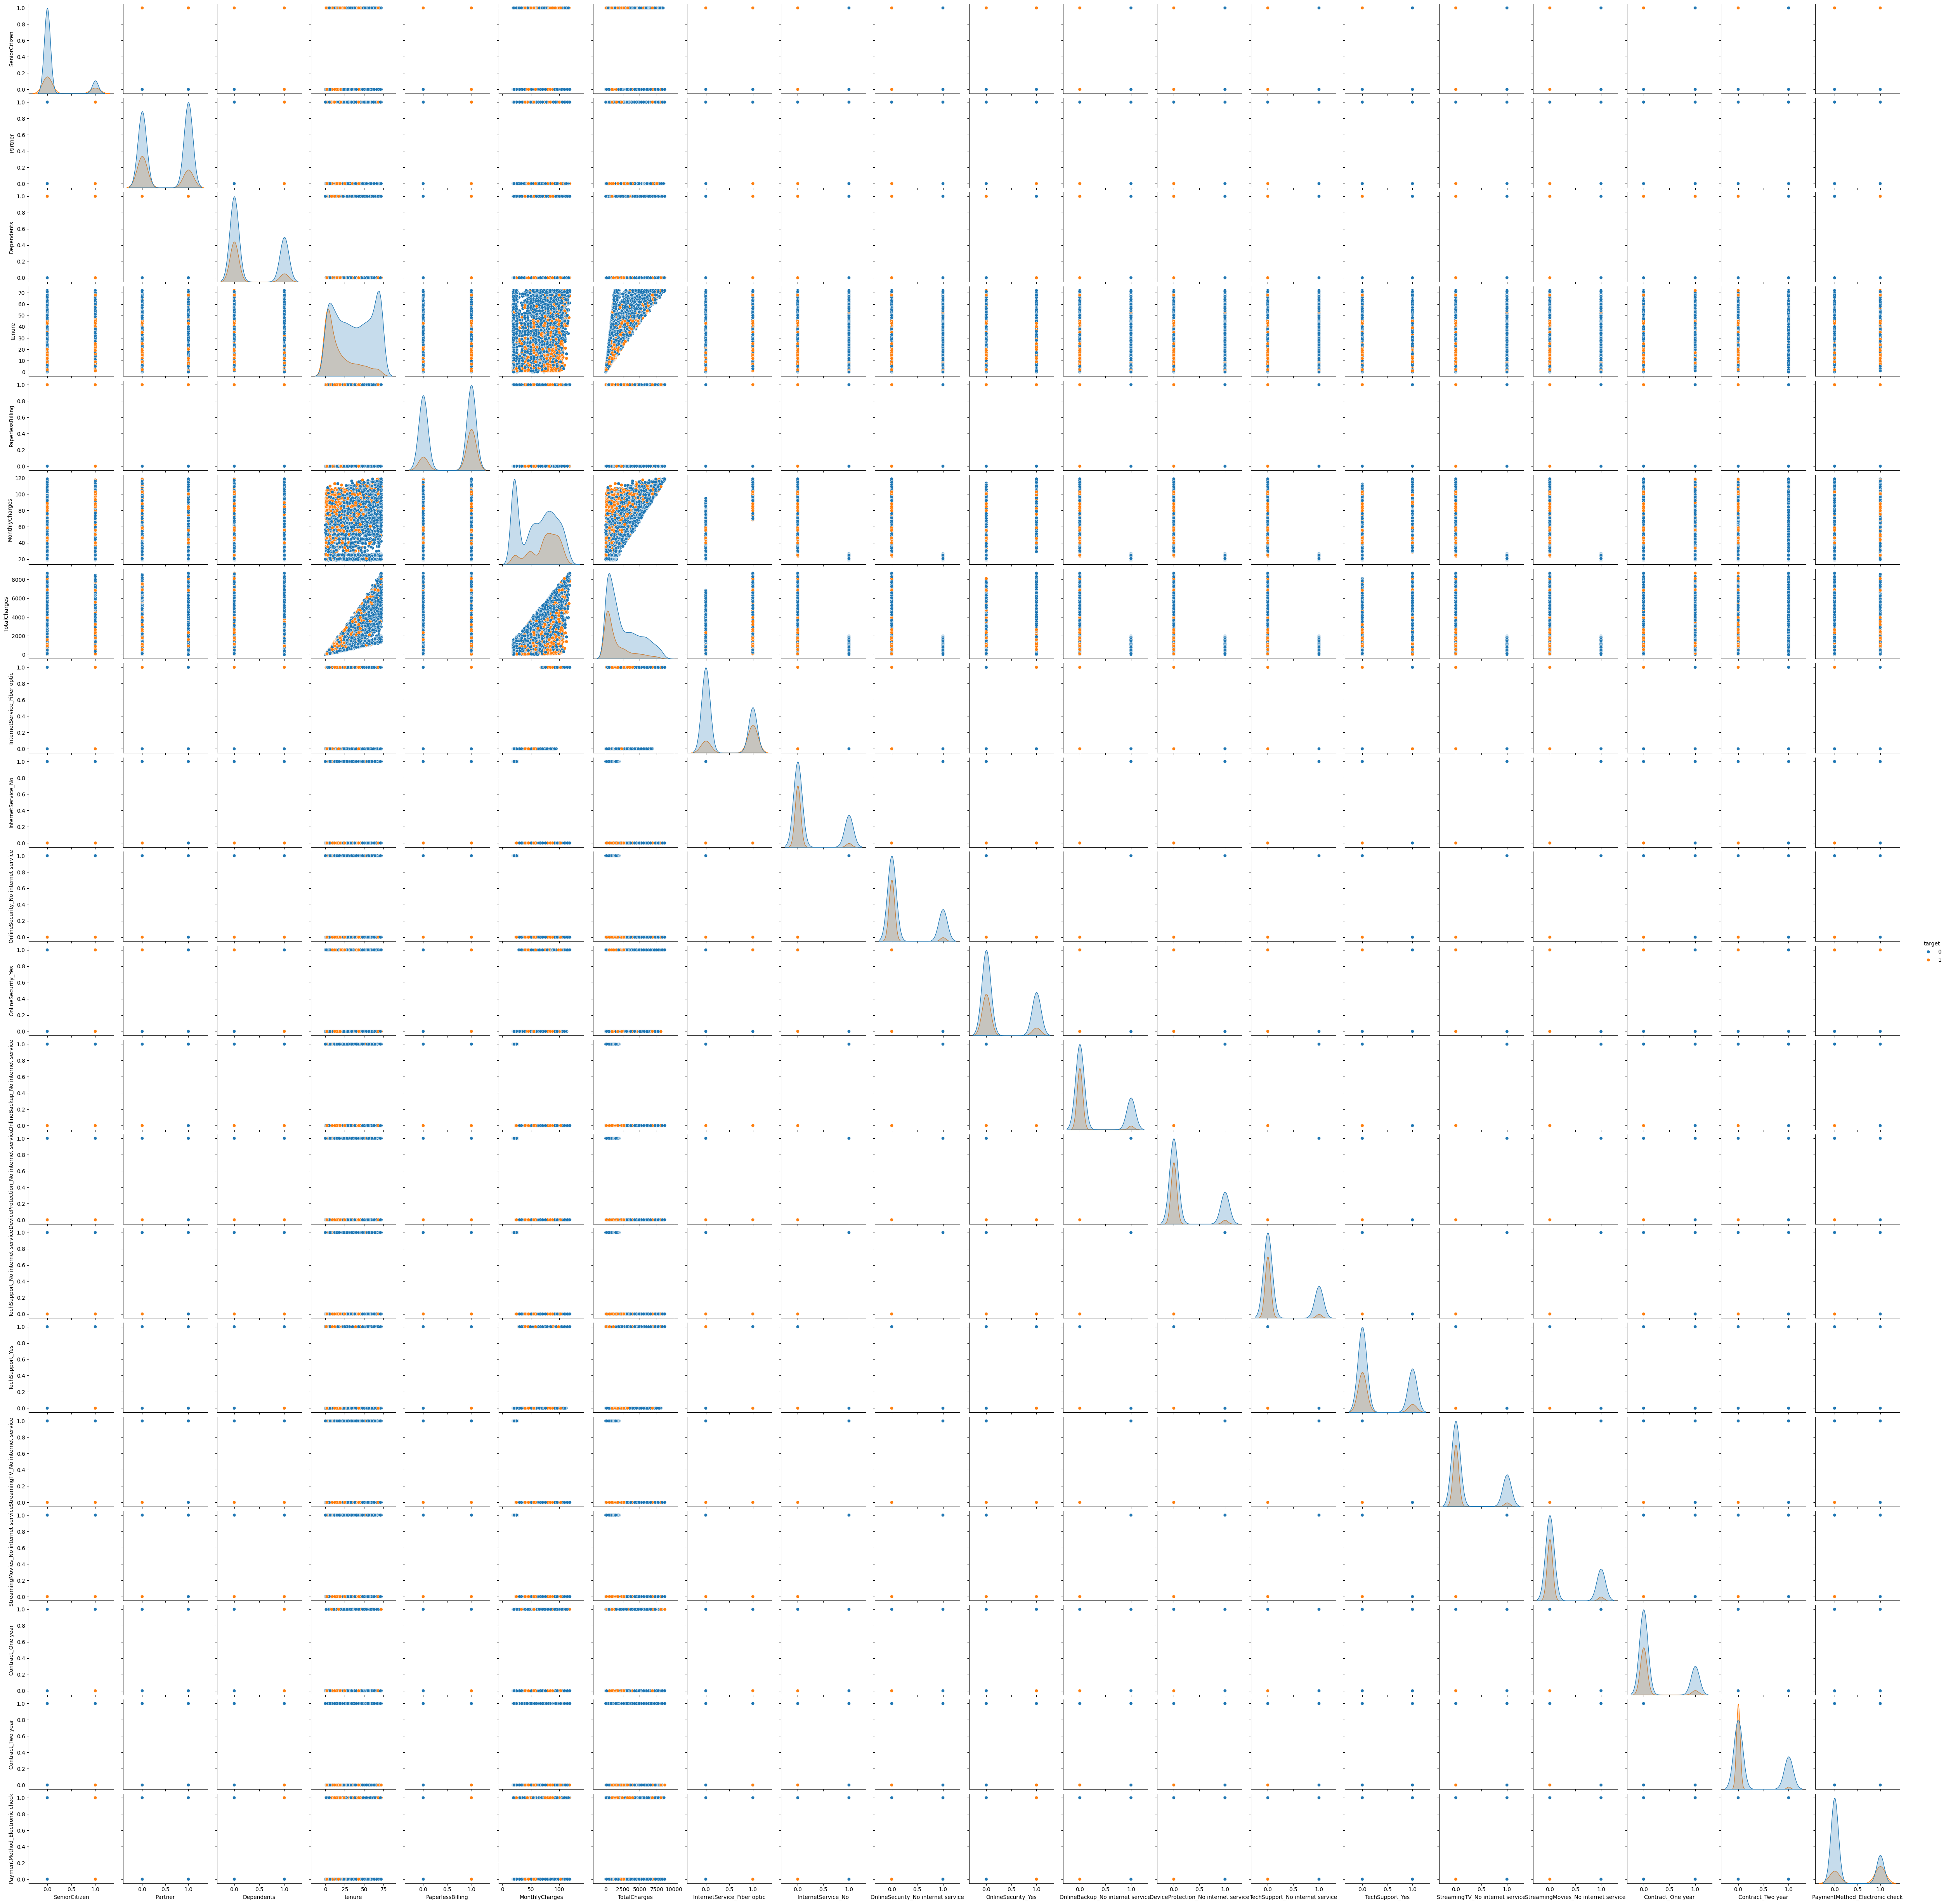

In [10]:
# 3. Get the feature names from your pipeline's preprocessing steps


X_transformed= pipeline_dt['clean'].transform(X_train)
X_filtered = pipeline_dt['ctf'].transform(X_transformed)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plot_df = pd.DataFrame(X_filtered)
plot_df['target'] = y_train.values
sns.pairplot(plot_df, hue='target')
plt.show()


In [ ]:
# import numpy as np
# from sklearn.metrics import f1_score, precision_score, recall_score

# thresholds = np.arange(0.25, 0.66, 0.01)
# for t in thresholds:
#     y_pred = (y_prob_dt > t).astype(int)
#     print(f"thresh={t:.2f} | P={precision_score(y_test,y_pred):.2f} | R={recall_score(y_test,y_pred):.2f} | F1={f1_score(y_test,y_pred):.2f}")


In [ ]:
import pandas as pd

# 1. Get the trained model from your pipeline
model = pipeline_dt['pridict_thresh'].model

# 2. Get the feature importances (scores of how much the tree uses each feature)
importances = model.feature_importances_




# 4. Combine them into a clean DataFrame and sort by most important
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

active_features = feature_importance_df

print("=== Features Used by the Decision Tree (Ranked by Importance) ===")
print(active_features.to_string(index=False))

In [ ]:
feature_names

In [ ]:

sample_output = pipeline_dt['clean'].transform(X_train.head(5))
sample_output = pipeline_dt['ctf'].transform(sample_output)
feature_names = list(sample_output.columns)

In [ ]:
from trace_path import trace_customer_path
import trace_path

X_transformed = pipeline_dt['clean'].transform(X_train.head(1))
X_filtered = pipeline_dt['ctf'].transform(X_transformed)
trace_customer_path(pipeline_dt, X_filtered )